# 08 — VotingClassifier (assemblage de modèles)

**Projet** : ObRail MSPR 2025-2026
**Source** : `data/processed/X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`

**Objectif** : Axe d'amélioration n°4 demandé par le professeur — tester un **VotingClassifier** (ensemble method) plutôt qu'une simple comparaison où un seul modèle gagne.

**Différence avec `03_models.ipynb`** :
- Dans `03_models.ipynb`, 4 modèles sont comparés et **un seul survit** (LightGBM, le meilleur F1).
- Ici, les 4 modèles **votent ensemble** sur chaque prédiction. Aucun n'est éliminé : leurs probabilités sont moyennées (soft voting) pour produire une décision collective.

**Type de vote retenu** : `voting='soft'` — on moyenne les probabilités plutôt que les votes binaires, ce qui est plus adapté à un dataset déséquilibré (19,4% de sous-dessertes) et permet de continuer à calculer le ROC-AUC, cohérent avec le reste du pipeline.

**Modèles assemblés** (mêmes hyperparamètres que `03_models.ipynb`, pour rester strictement comparable) :
1. Régression Logistique
2. Random Forest
3. LightGBM
4. MLP

In [1]:
## 0. Imports et configuration
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import json
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

SEED = 42
np.random.seed(SEED)


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for folder in [cwd] + list(cwd.parents):
        if (folder / 'data').exists() and (folder / 'src').exists() and (folder / 'models').exists():
            return folder
    raise FileNotFoundError('Could not find project root from current working directory')

ROOT = find_project_root()
PROCESSED_DIR = ROOT / 'data' / 'processed'
MODELS_DIR = ROOT / 'models'
EVAL_DIR = ROOT / 'evaluation'
PLOT_DIR = ROOT / 'evaluation' / 'plots'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Imports OK')

Imports OK


In [2]:
## 1. Chargement des données
X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'Taux underserved train : {y_train.mean()*100:.1f}%')
print(f'Taux underserved test  : {y_test.mean()*100:.1f}%')

X_train : (20160, 38)
X_test  : (5040, 38)
Taux underserved train : 19.4%
Taux underserved test  : 19.4%


## 2. Récupération des résultats individuels (référence)

Avant d'assembler les modèles, on recharge les résultats de `03_models.ipynb` pour pouvoir comparer le VotingClassifier aux 4 modèles pris séparément, sur la même base (`evaluation/model_comparison.csv`).

In [3]:
individual_results_path = EVAL_DIR / 'model_comparison.csv'

if individual_results_path.exists():
    individual_comparison = pd.read_csv(individual_results_path)
    print('Résultats individuels (03_models.ipynb) :')
    display(individual_comparison)
else:
    print('⚠️  evaluation/model_comparison.csv introuvable — relancer 03_models.ipynb avant ce notebook.')
    individual_comparison = None

Résultats individuels (03_models.ipynb) :


,Modèle,CV F1 (mean),CV F1 (±std),CV AUC (mean),CV AUC (±std),Test F1,Test AUC
0,LightGBM,0.6119,0.0075,0.8820,0.0036,0.6050,0.8826
1,Random Forest,0.5722,0.0070,0.8738,0.0050,0.5817,0.8707
2,Logistic Regression,0.5782,0.0121,0.8688,0.0045,0.5680,0.8653
3,MLP,0.3681,0.0955,0.8848,0.0044,0.3863,0.8815


## 3. Définition des 4 modèles de base

Mêmes hyperparamètres que `03_models.ipynb`, pour que la comparaison VotingClassifier vs modèles individuels soit strictement équitable (pas de biais introduit par un réglage différent).

In [4]:
# Ratio pour LightGBM : nombre de négatifs / nombre de positifs
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'scale_pos_weight pour LightGBM : {scale_pos_weight:.2f}')

log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=SEED,
)

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=1,
)

lgbm = LGBMClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=200,
    random_state=SEED,
    n_jobs=1,
    verbose=-1,
)

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=300,
    random_state=SEED,
    early_stopping=True,
    validation_fraction=0.1,
)

print('4 modèles de base définis : Logistic Regression, Random Forest, LightGBM, MLP')

scale_pos_weight pour LightGBM : 4.16
4 modèles de base définis : Logistic Regression, Random Forest, LightGBM, MLP


## 4. Construction du VotingClassifier

`voting='soft'` : la prédiction finale est la moyenne des probabilités prédites par chaque modèle (plutôt qu'un simple vote majoritaire). C'est plus adapté à notre dataset déséquilibré et permet de garder le ROC-AUC comme métrique de comparaison.

Les 4 modèles sont entraînés **à l'intérieur** du VotingClassifier — `scikit-learn` les ré-entraîne automatiquement sur `X_train` lors du `.fit()`.

In [5]:
voting_clf = VotingClassifier(
    estimators=[
        ('logreg', log_reg),
        ('rf', rf),
        ('lgbm', lgbm),
        ('mlp', mlp),
    ],
    voting='soft',
    n_jobs=1,
)

print('VotingClassifier construit avec 4 estimateurs (soft voting)')
voting_clf

VotingClassifier construit avec 4 estimateurs (soft voting)


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('logreg', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",1
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0


## 5. Entraînement et évaluation

Même protocole que `03_models.ipynb` : cross-validation 5-fold sur `X_train`, puis entraînement complet et évaluation finale sur `X_test`.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print('Cross-validation 5-fold du VotingClassifier...')
cv_f1  = cross_val_score(voting_clf, X_train, y_train, cv=cv, scoring='f1', n_jobs=1)
cv_auc = cross_val_score(voting_clf, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=1)

print(f'CV F1      : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print(f'CV ROC-AUC : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')

print('\nEntraînement final sur X_train complet...')
voting_clf.fit(X_train, y_train)

y_pred       = voting_clf.predict(X_test)
y_pred_proba = voting_clf.predict_proba(X_test)[:, 1]

test_f1  = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_proba)

print(f'\nTest F1    : {test_f1:.4f}')
print(f'Test AUC   : {test_auc:.4f}')
print('\nClassification report :')
print(classification_report(y_test, y_pred,
      target_names=['Non sous-desservi', 'Sous-desservi']))

voting_results = {
    'cv_f1_mean':   cv_f1.mean(),
    'cv_f1_std':    cv_f1.std(),
    'cv_auc_mean':  cv_auc.mean(),
    'cv_auc_std':   cv_auc.std(),
    'test_f1':      test_f1,
    'test_auc':     test_auc,
    'y_pred':       y_pred,
    'y_pred_proba': y_pred_proba,
}

Cross-validation 5-fold du VotingClassifier...
CV F1      : 0.6001 ± 0.0056
CV ROC-AUC : 0.8867 ± 0.0046

Entraînement final sur X_train complet...

Test F1    : 0.5989
Test AUC   : 0.8848

Classification report :
                   precision    recall  f1-score   support

Non sous-desservi       0.95      0.78      0.86      4063
    Sous-desservi       0.47      0.81      0.60       977

         accuracy                           0.79      5040
        macro avg       0.71      0.80      0.73      5040
     weighted avg       0.85      0.79      0.81      5040



## 6. Comparaison VotingClassifier vs modèles individuels

On ajoute le VotingClassifier au tableau comparatif existant pour voir s'il surpasse les 4 modèles pris séparément.

In [7]:
voting_row = pd.DataFrame([{
    'Modèle': 'VotingClassifier (soft)',
    'CV F1 (mean)': voting_results['cv_f1_mean'],
    'CV F1 (±std)': voting_results['cv_f1_std'],
    'CV AUC (mean)': voting_results['cv_auc_mean'],
    'CV AUC (±std)': voting_results['cv_auc_std'],
    'Test F1': voting_results['test_f1'],
    'Test AUC': voting_results['test_auc']
}])

if individual_comparison is not None:
    full_comparison = pd.concat([individual_comparison, voting_row], ignore_index=True)
else:
    full_comparison = voting_row
    
full_comparison['Test F1'] = pd.to_numeric(full_comparison['Test F1'])
full_comparison['Test AUC'] = pd.to_numeric(full_comparison['Test AUC'])

full_comparison = (
    full_comparison
    .sort_values('Test F1', ascending=False)
    .reset_index(drop=True)
)
print('Tableau comparatif complet (4 modèles individuels + VotingClassifier) :')
display(full_comparison.round(4))

full_comparison.to_csv(EVAL_DIR / 'model_comparison_with_voting.csv', index=False)
print('\n✅ Sauvegardé → evaluation/model_comparison_with_voting.csv')

Tableau comparatif complet (4 modèles individuels + VotingClassifier) :


,Modèle,CV F1 (mean),CV F1 (±std),CV AUC (mean),CV AUC (±std),Test F1,Test AUC
0,LightGBM,0.6119,0.0075,0.8820,0.0036,0.6050,0.8826
1,VotingClassifier (soft),0.6001,0.0056,0.8867,0.0046,0.5989,0.8848
2,Random Forest,0.5722,0.0070,0.8738,0.0050,0.5817,0.8707
3,Logistic Regression,0.5782,0.0121,0.8688,0.0045,0.5680,0.8653
4,MLP,0.3681,0.0955,0.8848,0.0044,0.3863,0.8815



✅ Sauvegardé → evaluation/model_comparison_with_voting.csv


## 7. Visualisations

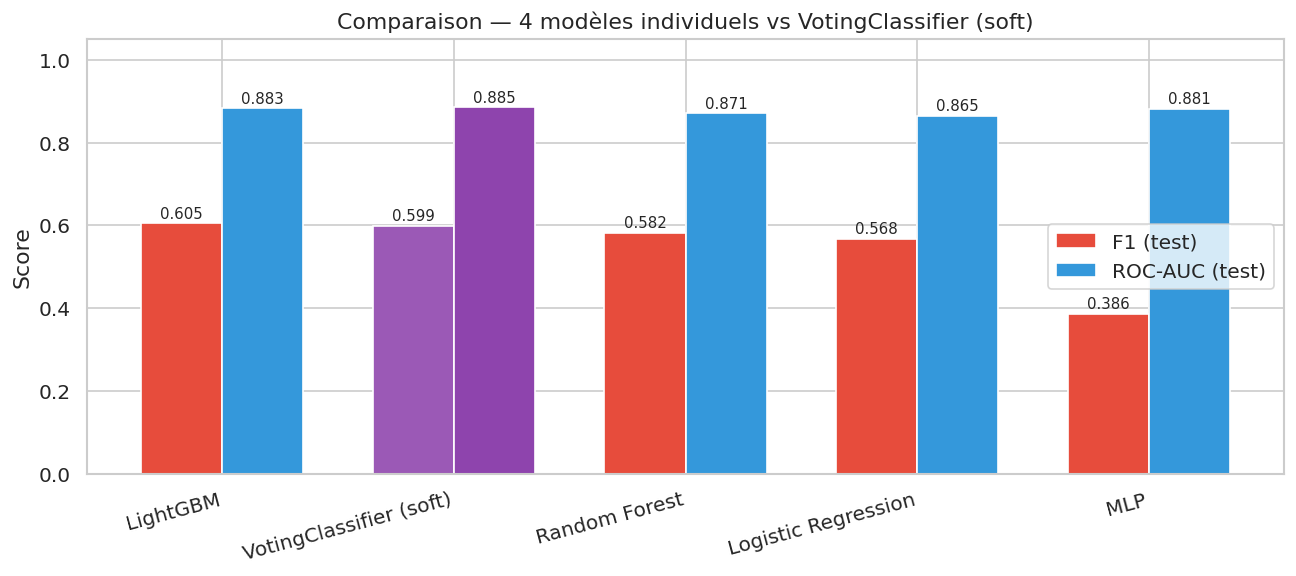

In [8]:
### 7.1 Comparaison F1 et ROC-AUC (avec VotingClassifier)
names_plot = full_comparison['Modèle'].tolist()
f1_plot    = full_comparison['Test F1'].astype(float).tolist()
auc_plot   = full_comparison['Test AUC'].astype(float).tolist()

x = np.arange(len(names_plot))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
colors_f1  = ['#9b59b6' if 'Voting' in n else '#e74c3c' for n in names_plot]
colors_auc = ['#8e44ad' if 'Voting' in n else '#3498db' for n in names_plot]

bars1 = ax.bar(x - w/2, f1_plot,  width=w, label='F1 (test)',      color=colors_f1)
bars2 = ax.bar(x + w/2, auc_plot, width=w, label='ROC-AUC (test)', color=colors_auc)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(names_plot, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Comparaison — 4 modèles individuels vs VotingClassifier (soft)')
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'voting_comparison.png')
plt.show()

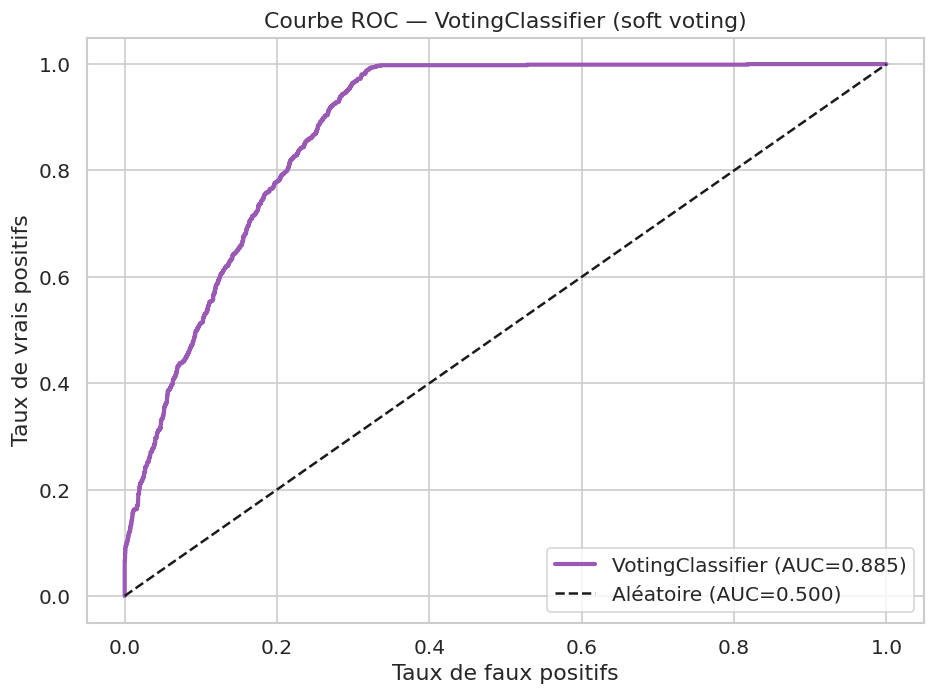

In [9]:
### 7.2 Courbe ROC du VotingClassifier
fig, ax = plt.subplots(figsize=(8, 6))

fpr, tpr, _ = roc_curve(y_test, voting_results['y_pred_proba'])
ax.plot(fpr, tpr, color='#9b59b6', linewidth=2.5,
        label=f"VotingClassifier (AUC={voting_results['test_auc']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC=0.500)')

ax.set_xlabel('Taux de faux positifs')
ax.set_ylabel('Taux de vrais positifs')
ax.set_title('Courbe ROC — VotingClassifier (soft voting)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'voting_roc_curve.png')
plt.show()

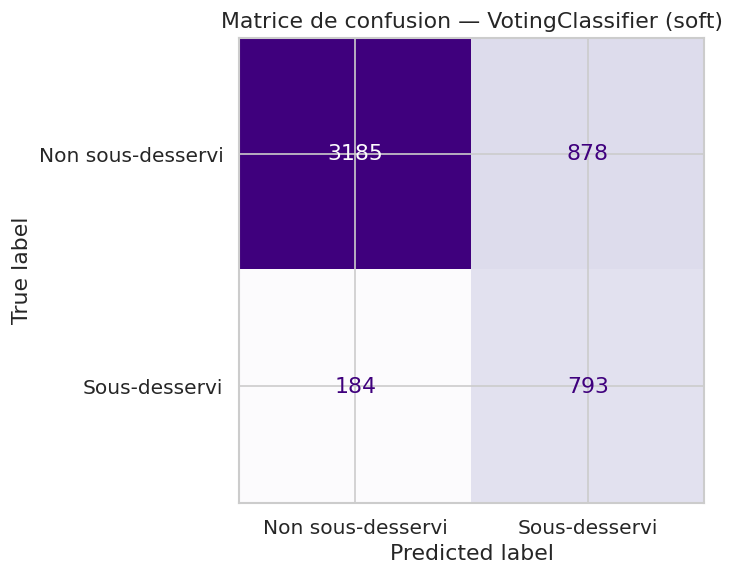

In [10]:
### 7.3 Matrice de confusion du VotingClassifier
cm = confusion_matrix(y_test, voting_results['y_pred'])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non sous-desservi', 'Sous-desservi']
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Purples')
ax.set_title('Matrice de confusion — VotingClassifier (soft)')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'voting_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 8. Analyse et décision

On compare le VotingClassifier au meilleur modèle individuel (`best_model.joblib`, sélectionné dans `03_models.ipynb`) pour décider s'il doit devenir le nouveau modèle de référence du projet.

In [11]:
# Récupération du meilleur modèle individuel pour comparaison directe
with open(MODELS_DIR / 'model_metadata.json') as f:
    individual_metadata = json.load(f)

best_individual_name = individual_metadata['model_name']
best_individual_f1    = individual_metadata['test_f1']
best_individual_auc   = individual_metadata['test_roc_auc']

print(f'Meilleur modèle individuel : {best_individual_name}')
print(f'  Test F1  : {best_individual_f1}')
print(f'  Test AUC : {best_individual_auc}')

print(f'\nVotingClassifier (soft) :')
print(f'  Test F1  : {voting_results["test_f1"]:.4f}')
print(f'  Test AUC : {voting_results["test_auc"]:.4f}')

f1_gain  = voting_results['test_f1']  - best_individual_f1
auc_gain = voting_results['test_auc'] - best_individual_auc

print(f'\nGain F1  (Voting - {best_individual_name}) : {f1_gain:+.4f}')
print(f'Gain AUC (Voting - {best_individual_name}) : {auc_gain:+.4f}')

if f1_gain > 0:
    print('\n✅ Le VotingClassifier surpasse le meilleur modèle individuel sur le F1.')
else:
    print('\n➡️  Le VotingClassifier n\'améliore pas le F1 par rapport au meilleur modèle individuel.')
    print('   Ceci reste une information utile : cela confirme que LightGBM capture déjà')
    print('   la majorité du signal disponible, et que les modèles plus faibles (LogReg, MLP)')
    print('   diluent légèrement la décision plutôt que de l\'enrichir.')

Meilleur modèle individuel : LightGBM (GridSearch)
  Test F1  : 0.6033
  Test AUC : 0.8811

VotingClassifier (soft) :
  Test F1  : 0.5989
  Test AUC : 0.8848

Gain F1  (Voting - LightGBM (GridSearch)) : -0.0044
Gain AUC (Voting - LightGBM (GridSearch)) : +0.0037

➡️  Le VotingClassifier n'améliore pas le F1 par rapport au meilleur modèle individuel.
   Ceci reste une information utile : cela confirme que LightGBM capture déjà
   la majorité du signal disponible, et que les modèles plus faibles (LogReg, MLP)
   diluent légèrement la décision plutôt que de l'enrichir.


## 9. Sauvegarde

Le VotingClassifier est sauvegardé séparément du modèle final retenu pour le projet (`best_model_optimized.joblib`), afin de ne pas perturber le pipeline existant (`src/predict.py`, l'API FastAPI). Il constitue une **preuve de la démarche d'exploration des ensemble methods** demandée par le professeur, indépendamment du choix final.

In [12]:
voting_path = MODELS_DIR / 'voting_classifier.joblib'
joblib.dump(voting_clf, voting_path)

voting_metadata = {
    'model_name':    'VotingClassifier (soft)',
    'estimators':    ['Logistic Regression', 'Random Forest', 'LightGBM', 'MLP'],
    'voting':        'soft',
    'test_f1':       round(voting_results['test_f1'], 4),
    'test_roc_auc':  round(voting_results['test_auc'], 4),
    'cv_f1_mean':    round(voting_results['cv_f1_mean'], 4),
    'cv_auc_mean':   round(voting_results['cv_auc_mean'], 4),
    'compared_to':   best_individual_name,
    'f1_gain_vs_best_individual':  round(f1_gain, 4),
    'auc_gain_vs_best_individual': round(auc_gain, 4),
    'features':      list(X_train.columns),
    'target':        'is_underserved',
    'seed':          SEED,
}

with open(MODELS_DIR / 'voting_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(voting_metadata, f, indent=2, ensure_ascii=False)

print(f'✅ VotingClassifier sauvegardé -> {voting_path}')
print(f'✅ Métadonnées sauvegardées -> models/voting_metadata.json')
print('\nContenu metadata :')
print(json.dumps(voting_metadata, indent=2, ensure_ascii=False))

✅ VotingClassifier sauvegardé -> /mnt/c/Users/charl/Desktop/EPSI-IA/MSPR/MSPR - 2/OBRail-MSPR2/models/voting_classifier.joblib
✅ Métadonnées sauvegardées -> models/voting_metadata.json

Contenu metadata :
{
  "model_name": "VotingClassifier (soft)",
  "estimators": [
    "Logistic Regression",
    "Random Forest",
    "LightGBM",
    "MLP"
  ],
  "voting": "soft",
  "test_f1": 0.5989,
  "test_roc_auc": 0.8848,
  "cv_f1_mean": 0.6001,
  "cv_auc_mean": 0.8867,
  "compared_to": "LightGBM (GridSearch)",
  "f1_gain_vs_best_individual": -0.0044,
  "auc_gain_vs_best_individual": 0.0037,
  "features": [
    "rail_modal_share",
    "type_encoded",
    "is_international",
    "log_distance",
    "log_co2",
    "country_AT",
    "country_BE",
    "country_BG",
    "country_CH",
    "country_CZ",
    "country_DE",
    "country_DK",
    "country_EE",
    "country_ES",
    "country_FI",
    "country_FR",
    "country_GB",
    "country_GR",
    "country_HR",
    "country_HU",
    "country_IE",
    "c

## 10. Récapitulatif

**Ce qui a été fait**
- Construction d'un `VotingClassifier` (soft voting) assemblant les 4 modèles candidats de `03_models.ipynb` : Logistic Regression, Random Forest, LightGBM, MLP
- Entraînement et validation croisée 5-fold, dans les mêmes conditions que la comparaison individuelle
- Comparaison directe avec le meilleur modèle individuel (LightGBM) sur F1 et ROC-AUC
- Visualisations dédiées : comparaison globale, courbe ROC, matrice de confusion
- Sauvegarde du VotingClassifier et de ses métadonnées, indépendamment du modèle final retenu pour l'API

**Pourquoi le soft voting plutôt que le hard voting**
Le soft voting moyenne les probabilités plutôt que les votes binaires, ce qui est plus adapté à notre dataset déséquilibré (19,4% de sous-dessertes) et permet de continuer à utiliser le ROC-AUC comme métrique de comparaison, cohérente avec le reste du pipeline.

**Lien avec le cahier des charges**
Cette étape répond explicitement à la demande du jury de tester une méthode d'assemblage (ensemble method) en complément de la comparaison classique entre modèles candidats déjà réalisée dans `03_models.ipynb`.

**Fichiers produits**
- `evaluation/model_comparison_with_voting.csv`
- `evaluation/plots/voting_comparison.png`
- `evaluation/plots/voting_roc_curve.png`
- `evaluation/plots/voting_confusion_matrix.png`
- `models/voting_classifier.joblib`
- `models/voting_metadata.json`